In [357]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # 충돌 허용
os.environ["OMP_NUM_THREADS"] = "1"            # OpenMP 병렬 스레드 최소화
os.environ["MKL_NUM_THREADS"] = "1"            # NumPy/MKL 병렬 제한

In [358]:
# !pip install --no-index --no-deps --find-links=/kaggle/input/recod-ai monai segmentation-models-pytorch timm

# **Init setting**

In [359]:
import os
import gc
import cv2
import h5py
import json
import random
import warnings
from time import time
from datetime import timedelta
from collections import defaultdict
from typing import Optional, Union

import numpy as np
import numpy.typing as npt
import pandas as pd
import scipy.optimize
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import torch.nn.init as init

import numba
from numba import types

import segmentation_models_pytorch as smp

warnings.filterwarnings('ignore')

# **Utils**

In [360]:

class ParticipantVisibleError(Exception):
    pass


def str_to_device(device:Union[torch.device,str]) -> torch.device:
    if not (isinstance(device, torch.device) or isinstance(device, str)):
        raise ValueError("device must torch.device or str")
    elif isinstance(device, str):
        device = torch.device(device)

    return device

def preprocessing(img:np.ndarray, img_size:int, interpolation=cv2.INTER_NEAREST, div=255.0):
    """
    Return Normalize and resize img
    """
    return cv2.resize(img.astype(np.float32) / div, (img_size, img_size), interpolation=interpolation)
    
def postprocessing(proba_map:np.ndarray, original_size:tuple[int, int], threshold:float, low_conf_max_prob:float, low_viz_thr:float, low_conf_min_pixel:int):
    # DEBUG
    # print("[DEBUG] Forged pixel num before PostProcessing: ", (proba_map > threshold).astype(np.uint8).sum())
    if is_low_confidence(proba_map, low_conf_max_prob, low_viz_thr, low_conf_min_pixel):
        # print("[DEBUG]: low_confidence")
        proba_map = np.zeros_like(proba_map)

    #후에 bilinear사용 고려
    proba_map = cv2.resize(proba_map, (original_size[1], original_size[0]), interpolation=cv2.INTER_NEAREST) # (W, H)
    mask_pred = (proba_map > threshold).astype(np.uint8)

    #PostProcessing
    kernel = np.ones((3,3), np.uint8)
    mask_pred = cv2.morphologyEx(mask_pred, cv2.MORPH_OPEN, kernel)
    mask_pred = cv2.morphologyEx(mask_pred, cv2.MORPH_CLOSE, kernel)

    return mask_pred

@numba.jit(nopython=True)
def _rle_encode_jit(x: npt.NDArray, fg_val: int = 1) -> list[int]:
    """Numba-jitted RLE encoder."""
    dots = np.where(x.T.flatten() == fg_val)[0]
    run_lengths = []
    prev = -2
    for b in dots:
        if b > prev + 1:
            run_lengths.extend((b + 1, 0))
        run_lengths[-1] += 1
        prev = b
    return run_lengths


def rle_encode(masks: list[npt.NDArray], fg_val: int = 1) -> str:
    """
    Adapted from contrails RLE https://www.kaggle.com/code/inversion/contrails-rle-submission
    Args:
        masks: list of numpy array of shape (height, width), 1 - mask, 0 - background
    Returns: run length encodings as a string, with each RLE JSON-encoded and separated by a semicolon.
    """
    return ';'.join([json.dumps(_rle_encode_jit(x, fg_val)) for x in masks])


@numba.njit
def _rle_decode_jit(mask_rle: npt.NDArray, height: int, width: int) -> npt.NDArray:
    """
    s: numpy array of run-length encoding pairs (start, length)
    shape: (height, width) of array to return
    Returns numpy array, 1 - mask, 0 - background
    """
    if len(mask_rle) % 2 != 0:
        # Numba requires raising a standard exception.
        raise ValueError('One or more rows has an odd number of values.')

    starts, lengths = mask_rle[0::2], mask_rle[1::2]
    starts -= 1
    ends = starts + lengths
    for i in range(len(starts) - 1):
        if ends[i] > starts[i + 1]:
            raise ValueError('Pixels must not be overlapping.')
    img = np.zeros(height * width, dtype=np.bool_)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img


def rle_decode(mask_rle: str, shape: tuple[int, int]) -> npt.NDArray:
    """
    mask_rle: run-length as string formatted (start length)
              empty predictions need to be encoded with '-'
    shape: (height, width) of array to return
    Returns numpy array, 1 - mask, 0 - background
    """

    mask_rle = json.loads(mask_rle)
    mask_rle = np.asarray(mask_rle, dtype=np.int32)
    starts = mask_rle[0::2]
    if sorted(starts) != list(starts):
        raise ParticipantVisibleError('Submitted values must be in ascending order.')
    try:
        return _rle_decode_jit(mask_rle, shape[0], shape[1]).reshape(shape, order='F')
    except ValueError as e:
        raise ParticipantVisibleError(str(e)) from e


def calculate_f1_score(pred_mask: npt.NDArray, gt_mask: npt.NDArray):
    pred_flat = pred_mask.flatten()
    gt_flat = gt_mask.flatten()

    tp = np.sum((pred_flat == 1) & (gt_flat == 1))
    fp = np.sum((pred_flat == 1) & (gt_flat == 0))
    fn = np.sum((pred_flat == 0) & (gt_flat == 1))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    if (precision + recall) > 0:
        return 2 * (precision * recall) / (precision + recall)
    else:
        return 0


def calculate_f1_matrix(pred_masks: list[npt.NDArray], gt_masks: list[npt.NDArray]):
    """
    Parameters:
    pred_masks (np.ndarray):
            First dimension is the number of predicted instances.
            Each instance is a binary mask of shape (height, width).
    gt_masks (np.ndarray):
            First dimension is the number of ground truth instances.
            Each instance is a binary mask of shape (height, width).
    """

    num_instances_pred = len(pred_masks)
    num_instances_gt = len(gt_masks)
    f1_matrix = np.zeros((num_instances_pred, num_instances_gt))

    # Calculate F1 scores for each pair of predicted and ground truth masks
    for i in range(num_instances_pred):
        for j in range(num_instances_gt):
            pred_flat = pred_masks[i].flatten()
            gt_flat = gt_masks[j].flatten()
            f1_matrix[i, j] = calculate_f1_score(pred_mask=pred_flat, gt_mask=gt_flat)

    if f1_matrix.shape[0] < len(gt_masks):
        # Add a row of zeros to the matrix if the number of predicted instances is less than ground truth instances
        f1_matrix = np.vstack((f1_matrix, np.zeros((len(gt_masks) - len(f1_matrix), num_instances_gt))))

    return f1_matrix


def oF1_score(pred_masks: list[npt.NDArray], gt_masks: list[npt.NDArray]):
    """
    Calculate the optimal F1 score for a set of predicted masks against
    ground truth masks which considers the optimal F1 score matching.
    This function uses the Hungarian algorithm to find the optimal assignment
    of predicted masks to ground truth masks based on the F1 score matrix.
    If the number of predicted masks is less than the number of ground truth masks,
    it will add a row of zeros to the F1 score matrix to ensure that the dimensions match.

    Parameters:
    pred_masks (list of np.ndarray): List of predicted binary masks.
    gt_masks (np.ndarray): Array of ground truth binary masks.
    Returns:
    float: Optimal F1 score.
    """
    f1_matrix = calculate_f1_matrix(pred_masks, gt_masks)

    # Find the best matching between predicted and ground truth masks
    row_ind, col_ind = scipy.optimize.linear_sum_assignment(-f1_matrix)
    # The linear_sum_assignment discards excess predictions so we need a separate penalty.
    excess_predictions_penalty = len(gt_masks) / max(len(pred_masks), len(gt_masks))
    return np.mean(f1_matrix[row_ind, col_ind]) * excess_predictions_penalty


def evaluate_single_image(label_rles: str, prediction_rles: str, shape_str: str) -> float:
    shape = json.loads(shape_str)
    label_rles = [rle_decode(x, shape=shape) for x in label_rles.split(';')]
    prediction_rles = [rle_decode(x, shape=shape) for x in prediction_rles.split(';')]
    return oF1_score(prediction_rles, label_rles)


def score(solution: pd.DataFrame, submission: pd.DataFrame, row_id_column_name: str) -> float:
    """
    Args:
        solution (pd.DataFrame): The ground truth DataFrame.
        submission (pd.DataFrame): The submission DataFrame.
        row_id_column_name (str): The name of the column containing row IDs.
    Returns:
        float

    Examples
    --------
    >>> solution = pd.DataFrame({'row_id': [0, 1, 2], 'annotation': ['authentic', 'authentic', 'authentic'], 'shape': ['authentic', 'authentic', 'authentic']})
    >>> submission = pd.DataFrame({'row_id': [0, 1, 2], 'annotation': ['authentic', 'authentic', 'authentic']})
    >>> score(solution.copy(), submission.copy(), row_id_column_name='row_id')
    1.0

    >>> solution = pd.DataFrame({'row_id': [0, 1, 2], 'annotation': ['authentic', 'authentic', 'authentic'], 'shape': ['authentic', 'authentic', 'authentic']})
    >>> submission = pd.DataFrame({'row_id': [0, 1, 2], 'annotation': ['[101, 102]', '[101, 102]', '[101, 102]']})
    >>> score(solution.copy(), submission.copy(), row_id_column_name='row_id')
    0.0

    >>> solution = pd.DataFrame({'row_id': [0, 1, 2], 'annotation': ['[101, 102]', '[101, 102]', '[101, 102]'], 'shape': ['[720, 960]', '[720, 960]', '[720, 960]']})
    >>> submission = pd.DataFrame({'row_id': [0, 1, 2], 'annotation': ['[101, 102]', '[101, 102]', '[101, 102]']})
    >>> score(solution.copy(), submission.copy(), row_id_column_name='row_id')
    1.0

    >>> solution = pd.DataFrame({'row_id': [0, 1, 2], 'annotation': ['[101, 103]', '[101, 102]', '[101, 102]'], 'shape': ['[720, 960]', '[720, 960]', '[720, 960]']})
    >>> submission = pd.DataFrame({'row_id': [0, 1, 2], 'annotation': ['[101, 102]', '[101, 102]', '[101, 102]']})
    >>> score(solution.copy(), submission.copy(), row_id_column_name='row_id')
    0.9983739837398374

    >>> solution = pd.DataFrame({'row_id': [0, 1, 2], 'annotation': ['[101, 102];[300, 100]', '[101, 102]', '[101, 102]'], 'shape': ['[720, 960]', '[720, 960]', '[720, 960]']})
    >>> submission = pd.DataFrame({'row_id': [0, 1, 2], 'annotation': ['[101, 102]', '[101, 102]', '[101, 102]']})
    >>> score(solution.copy(), submission.copy(), row_id_column_name='row_id')
    0.8333333333333334
    """
    df = solution
    df = df.rename(columns={'annotation': 'label'})

    df['prediction'] = submission['annotation']
    # Check for correct 'authentic' label
    authentic_indices = (df['label'] == 'authentic') | (df['prediction'] == 'authentic')
    df['image_score'] = ((df['label'] == df['prediction']) & authentic_indices).astype(float)

    df.loc[~authentic_indices, 'image_score'] = df.loc[~authentic_indices].apply(
        lambda row: evaluate_single_image(row['label'], row['prediction'], row['shape']), axis=1
    )
    return float(np.mean(df['image_score']))



def compute_pos_weight(
    dataset=None,
    masks_path=None,
    authentic_path=None,
    forgded_path=None,
    h5_path=None,
    img_size=128,
    mode="resized",
    authentic_included=True,
    interpolation=cv2.INTER_NEAREST,
):
    """
    Compute pos_weight for BCE loss based on forged pixel ratio.

    Args:
        dataset: HybridDataset instance (optional)
        masks_path: path to train_masks directory
        h5_path: path to HDF5 file
        img_size: target resize (for 'resized' mode)
        mode: 'resized' or 'original'
        authentic_included: if True, counts authentic (no mask) images as all-zero masks

    Returns:
        torch.Tensor: scalar pos_weight
    """
    forged_pixels = 0
    total_pixels = 0
    processed = 0

    # ✅ Case 1: HDF5 (resized mask 기준)
    if h5_path and os.path.exists(h5_path) and mode == "resized":
        print(f"📊 Loading resized mask stats from HDF5: {h5_path}")
        with h5py.File(h5_path, "r") as h5f:
            masks = h5f["masks"][:]
            forged_pixels = masks.sum()
            total_pixels = np.prod(masks.shape)
            processed = masks.shape[0]
    
    # ✅ Case 2: Raw mask 폴더 기준
    elif masks_path and os.path.exists(masks_path):
        print(f"📊 Scanning {'resized' if mode=='resized' else 'original'} masks in: {masks_path}")
        mask_files = [f"{f.split('.')[0]}.npy" for f in (os.listdir(authentic_path) + os.listdir(forgded_path)) if f.endswith(('.png', '.jpg', '.jpeg', ))]
        print(f"🗂 Found {len(mask_files)} mask files.")
        print("[DEBUG] First 5 mask files:", mask_files[:5])
        for f in tqdm(mask_files, leave=False):
            mask_path = os.path.join(masks_path, f)
            try:
                mask = np.load(mask_path)
                if mask.ndim == 3:
                    mask = mask.max(axis=0) if mask.shape[0] <= 10 else mask.max(axis=-1)
                if mode == "resized":
                    mask = cv2.resize(mask.astype(np.uint8), (img_size, img_size), interpolation=interpolation)
                mask = (mask > 0).astype(np.uint8)
            except Exception:
                # 🚨 mask 파일 깨졌거나 누락된 경우
                mask = np.zeros((img_size, img_size), dtype=np.uint8)

            forged_pixels += mask.sum()
            total_pixels += mask.size
            processed += 1

        # ✅ authentic (mask 없는 이미지)를 0-mask로 추가
        if authentic_included and dataset is not None:
            missing = len(dataset.samples) - processed
            if missing > 0:
                total_pixels += missing * (img_size ** 2)
                print(f"📦 Added {missing} authentic samples as 0-masks")

    else:
        raise ValueError("You must provide either h5_path or masks_path.")

    ratio = forged_pixels / (total_pixels + 1e-8)
    pos_weight = (1 - ratio) / (ratio + 1e-8)

    print(f"\n📈 Forged pixel ratio: {ratio:.8f}")
    print(f"⚖️ pos_weight = {pos_weight:.2f}  (mode={mode}, total={processed} samples)")
    return torch.tensor(pos_weight, dtype=torch.float32)


def mask_to_instances(mask, min_area: int = 1) -> list[np.ndarray]:
    """
    Convert a mask map to individual connected-component masks (instances).
    
    Args:
        mask (np.ndarray): Model output probability map (H, W)
        min_area (int): Minimum pixel area to keep an instance
        
    Returns:
        list[np.ndarray]: List of instance masks (each with shape (H, W))
    """
    if mask.ndim == 3:
        mask = mask.max(axis=0)

    mask  = mask.astype(np.uint8)
    # 2️⃣ 너무 작으면 아예 인스턴스 없음
    if mask.sum() < min_area:
        return []

    # 3️⃣ 연결된 영역 찾기 (Connected Components)
    num, lbl, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    instances = []
    for i in range(1, num):  # label=0은 background
        area = stats[i, cv2.CC_STAT_AREA]
        if area >= min_area:
            inst = (lbl == i).astype(np.uint8)  # 해당 label 위치만 1로
            instances.append(inst)

    return instances

def is_low_confidence(prob_map, low_conf_max_prob=0.5, low_viz_thr=0.06, low_conf_min_pixel=100):
    if float(prob_map.max()) >= low_conf_max_prob: #일단 “low confidence 아님으로 판단
        return False
    cover = int((prob_map >= low_viz_thr).sum()) #검출됨
    return cover < low_conf_min_pixel

@torch.no_grad()
def evaluate(
        model, val_loader, device:Union[torch.device,str], cls_loss_fn, dice_loss_fn, alpha=0.5, beta=0.5,
        interpolation=cv2.INTER_NEAREST, threshold=0.5, min_area=100,
        low_conf_max_prob=0.06, low_viz_thr=0.04, low_conf_min_pixel=128, scaler=None,
    ):
    model.eval()
    total_loss = 0
    cls_total = 0
    dice_total = 0
    solution = {'case_id': [], 'annotation': [], 'shape': []}
    file_path_list = []
    
    for imgs, masks, mask_path, is_forged in tqdm(val_loader, desc="Calculating Loss", leave=False):

        imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        with autocast(device_type=device.type, enabled=scaler is not None):
            logit_map = model(imgs)
            cls_loss = cls_loss_fn(logit_map, masks)
            dice_loss = dice_loss_fn(logit_map, masks)
            loss = alpha * cls_loss + beta * dice_loss

        total_loss += loss.item()
        cls_total += cls_loss.item()
        dice_total += dice_loss.item()

        for img, mask_path, is_forged in zip(imgs, mask_path, is_forged):

            img_path = mask_path2img_path(mask_path, is_forged)
            file_path_list.append(img_path)
            if is_forged:
                gt = np.load(mask_path)
            else:
                img = cv2.imread(img_path)
                w, h = img.shape[:2]
                gt = np.zeros((1, h, w))

            if gt.ndim == 3:
                gt = gt.max(axis=0)
            gt_instances = mask_to_instances(gt)

            case_id = os.path.splitext(os.path.basename(img_path))[0]
            solution['case_id'].append(int(case_id))
            rle_str = rle_encode(gt_instances)
            solution['annotation'].append("authentic" if len(gt_instances) == 0 else rle_str)
            solution['shape'].append(json.dumps([h,w]))

        
    total_loss = total_loss / len(val_loader)
    cls_total = cls_total / len(val_loader)
    dice_total = dice_total / len(val_loader)

    prediction= predict(
        model, None, device, test_path_file_list=file_path_list, img_size=img.shape[1],
        max_size=None, interpolation=interpolation, threshold=threshold, min_area=min_area,
        low_conf_max_prob=low_conf_max_prob, low_viz_thr=low_viz_thr, low_conf_min_pixel=low_conf_min_pixel,
    )
    del img, imgs, masks, logit_map, cls_loss, dice_loss, loss
    torch.cuda.empty_cache()

    if prediction['case_id'] != solution['case_id']:
        raise ValueError("Prediction`s Key and Solution`s key must be match")
    
    solution_df = pd.DataFrame(solution)
    prediction_df = pd.DataFrame(prediction)

    score_ = score(solution_df, prediction_df, row_id_column_name='case_id')

    return {"f1_score": score_, "loss_total": total_loss, "loss_cls": cls_total, "loss_dice": dice_total}

    



def mask_path2img_path(mask_path, is_forged):
    """
    Convert a mask path to its corresponding image path.
    If is_forged == 1 → train_images/forged/
       is_forged == 0 → train_images/authentic/

    Args:
        mask_path (str): e.g., "C:\\...\\train_masks\\10.npy"
        is_forged (int): 1 (forged) or 0 (authentic)

    Returns:
        str: full path to the matching image file
    """
    #  base directory split
    mask_dir, mask_file = os.path.split(mask_path)  # (폴더, 파일)
    parent_dir = os.path.dirname(mask_dir)          # train_masks 상위 폴더 (e.g., .../recodai-luc-scientific-image-forgery-detection)
    
    # train_images 하위 폴더 이름 결정
    subfolder = "forged" if is_forged else "authentic"

    # 확장자 없는 파일명 (예: '10')
    file_stem = os.path.splitext(mask_file)[0]

    # 이미지 경로 후보 생성
    img_dir = os.path.join(parent_dir, "train_images", subfolder)
    candidates = [os.path.join(img_dir, file_stem + ext) for ext in [".jpg", ".jpeg", ".png"]]

    # 존재하는 파일 찾기
    for path in candidates:
        if os.path.exists(path):
            return path

    raise FileNotFoundError(f"No corresponding image found for mask: {mask_path}")
        

def predict(model, test_path, device, test_path_file_list=None, img_size=128, max_size=None, interpolation=cv2.INTER_NEAREST, threshold=0.5, min_area=100, low_conf_max_prob = 0.06, low_viz_thr = 0.04, low_conf_min_pixel = 128, scaler: Optional[torch.amp.GradScaler] = None) -> dict[str, str]:

    """
    Return RLE string
    """
    device = str_to_device(device)
    device_type = device.type

    model.eval()
    predictions = {'case_id': [], 'annotation': []}
    if test_path_file_list is None:
        test_files = [f for f in os.listdir(test_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][:max_size]
    else:
        test_files = test_path_file_list
    with torch.no_grad():
        for file in tqdm(test_files, desc="Predicting", leave=False):
            case_id = file.split('.')[0]

            #Load Img
            if test_path is None:
                img_path = file
                case_id =  os.path.splitext(os.path.basename(img_path))[0]
            else:
                img_path = os.path.join(test_path, file)
            img = cv2.imread(img_path)
            original_size = img.shape[:2]
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            processed_img = preprocessing(img, img_size, interpolation)

            img_tensor = torch.from_numpy(processed_img)
            img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0).contiguous()
            img_tensor = img_tensor.to(device)

            with autocast(device_type=device_type, enabled=scaler is not None):
                logit_map = model(img_tensor)
                proba_map = torch.sigmoid(logit_map)

            proba_map = proba_map.squeeze().cpu().numpy()  # (H, W)
            mask_pred = postprocessing(proba_map, original_size, threshold, low_conf_max_prob, low_viz_thr, low_conf_min_pixel)
            case_id = int(case_id)
            #후에 resize하기 전으로 변경 (img_size 똑같을 때)
            if mask_pred.sum() < min_area:
                predictions['case_id'].append(case_id)
                predictions['annotation'].append("authentic")
                # print("[DEBUG]: min_area, ", mask_pred.sum())
            else:
                instances = mask_to_instances(mask_pred, min_area=min_area)
                predictions['case_id'].append(case_id)
                predictions['annotation'].append(
                    ("authentic" if len(instances) == 0 else rle_encode(instances))
                )

    return predictions


def set_seed(seed: int = 42):
    random.seed(seed)                        # Python 랜덤 시드
    np.random.seed(seed)                     # NumPy 랜덤 시드
    torch.manual_seed(seed)                  # PyTorch CPU 시드
    torch.cuda.manual_seed(seed)             # PyTorch GPU 시드
    torch.cuda.manual_seed_all(seed)         # Multi-GPU 환경일 때

    os.environ["PYTHONHASHSEED"] = str(seed) # 해시 시드 (Python 3.3+)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"  # (CUDA ≥10.2용) 완전 결정적 연산

    # ⚠️ PyTorch 연산의 결정론적(deterministic) 설정
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # PyTorch 2.0+ (optional): 결정론 모드 강제
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass

    print(f"✅ Seed fixed at: {seed}\n")



# **SMP U-Net CV Ensemble Predict**
* optional: USE TTA
* Infer only

## 1) Envoironment report

In [361]:
import sys, platform

DEVICE = 'cuda:0' if torch.cuda.is_available() else 'cpu'

print("Python: ", sys.version.split()[0])
print("OS: ", platform.platform())
print("Torch: ", torch.__version__)
print("DEVICE: ", DEVICE)

Python:  3.9.21
OS:  Windows-10-10.0.26100-SP0
Torch:  2.6.0+cu118
DEVICE:  cuda:0


## 2) Paths

In [362]:
COMP_DIR = r"C:\Users\user\.cache\kagglehub\competitions\recodai-luc-scientific-image-forgery-detection"
TEST_DIR = os.path.join(COMP_DIR, "test_images")
TRAIN_DIR = os.path.join(COMP_DIR, "train_images")
MODEL_PATH = os.path.join(r"Weights\FOLD1\best1.pth")

# Output
OUT_DIR = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)
SUB_PATH = os.path.join(OUT_DIR, "submission.csv")


print("COMP_DIR: ", COMP_DIR)
print("TEST_DIR: ", TEST_DIR)
print("TRAIN_DIR: ", TRAIN_DIR)
print("MODEL_PATH: ", MODEL_PATH)
print("SUB_PATH: ", SUB_PATH)
print("MODEL_PATH is exists: ", os.path.exists(MODEL_PATH))

COMP_DIR:  C:\Users\user\.cache\kagglehub\competitions\recodai-luc-scientific-image-forgery-detection
TEST_DIR:  C:\Users\user\.cache\kagglehub\competitions\recodai-luc-scientific-image-forgery-detection\test_images
TRAIN_DIR:  C:\Users\user\.cache\kagglehub\competitions\recodai-luc-scientific-image-forgery-detection\train_images
MODEL_PATH:  Weights\FOLD1\best1.pth
SUB_PATH:  /kaggle/working\submission.csv
MODEL_PATH is exists:  True


## 3) Parameters

In [363]:
import platform

def print_hparams():
    print("\n===== ⚙️ HYPERPARAMETERS =====")
    print(f"📏 Image Size: {IMG_SIZE}")
    print(f"📦 Batch Size: {BATCH_SIZE}")
    print(f"🔁 Num Epochs: {NUM_EPOCHS}")
    print(f"💡 Learning Rate: {LR}")
    print(f"🔢 Interpolation: {INTERPOLATION}")
    print("\n----- 🧮 Loss & Optimizer -----")
    print(f"BCE Loss: {bce_loss_cls.__name__}")
    print(f"Dice Loss: {dice_loss_cls.__name__}")
    print(f"Loss Weights → α: {alpha}, β: {beta}")
    print(f"Optimizer: {optimizer_cls.__name__}")
    print("\n----- 🧹 Post-Processing -----")
    print(f"Threshold: {THRESHOLD}")
    print(f"Min Area: {MIN_AREA}")
    print(f"Low Conf (Max Prob): {LOW_CONF_MAX_PROB}")
    print(f"Low Viz Thr: {LOW_VIZ_THR}")
    print(f"Low Conf (Min Pixel): {LOW_CONF_MIN_PIXEL}")
    print("\n----- ⚡ Acceleration -----")
    print(f"DEVICE: {DEVICE}")
    print(f"Pin Memory: {USE_PIN_MEM()}")
    print(f"Num Workers: {NUM_WORKERS}")
    print(f"Mixed Precision (AMP): {USE_AMP}")
    print(f"Platform: {platform.platform()}")
    print("===============================\n")


# Interpolation Method
INTERPOLATION = cv2.INTER_NEAREST

# Model Params
PARAMS = {
    "encoder_name": "efficientnet-b3", # Backbone
    "encoder_weights": None, # Pretrained Weights
    "in_channels":3, # Input Channel
    "classes": 1, #Output Channel
    "activation": None, 
}

# Learning HyperParams
IMG_SIZE = 256
BATCH_SIZE = 32
NUM_EPOCHS = 50
LR = 1e-4
bce_loss_cls = nn.BCEWithLogitsLoss
dice_loss_cls = smp.losses.DiceLoss
alpha = 0.5  # Weight for combining BCE and Dice losses
beta = 1 - alpha
optimizer_cls = torch.optim.Adam

# Post Processing HyperParams
THRESHOLD = 0.6
LOW_CONF_MAX_PROB = 0.06
LOW_VIZ_THR = 0.04
LOW_CONF_MIN_PIXEL = 128
MIN_AREA = 64
THRESHOLD = 0.5
MIN_AREA = 16
TRAIN_SAMPLE_NUM = None
TEST_SAMPLE_NUM = None


# Aceleration Params -> Default: cpu settings
USE_PIN_MEM = torch.cuda.is_available
NUM_WORKERS = 4 if torch.cuda.is_available() and "Windows" not in platform.platform() else 0
USE_AMP = True

print_hparams()


===== ⚙️ HYPERPARAMETERS =====
📏 Image Size: 256
📦 Batch Size: 32
🔁 Num Epochs: 50
💡 Learning Rate: 0.0001
🔢 Interpolation: 0

----- 🧮 Loss & Optimizer -----
BCE Loss: BCEWithLogitsLoss
Dice Loss: DiceLoss
Loss Weights → α: 0.5, β: 0.5
Optimizer: Adam

----- 🧹 Post-Processing -----
Threshold: 0.5
Min Area: 16
Low Conf (Max Prob): 0.06
Low Viz Thr: 0.04
Low Conf (Min Pixel): 128

----- ⚡ Acceleration -----
DEVICE: cuda:0
Pin Memory: True
Num Workers: 0
Mixed Precision (AMP): True
Platform: Windows-10-10.0.26100-SP0



## 4) Dataset

In [364]:
class HybridDataset(Dataset):
    """
    Hybrid lazy/full-memory dataset.
    Supports loading from HDF5 (lazy) or fully preloading into memory.
    """

    def __init__(self, h5_path: str,
                 authentic_path: str,
                 forged_path: str,
                 masks_path: str,
                 img_size=128,
                 is_train=True,
                 preload=False,
                 verbose=False,
                 interpolation=cv2.INTER_NEAREST,
                 train_sample_num=None,
                 test_sample_num=None
                ):
        """
        Args:
            h5_path: path to .h5 file (will be created if not exists)
            authentic_path, forged_path, masks_path: image & mask directories
            img_size: resize target
            preload: whether to fully load into memory
        """

        self.h5_path = h5_path
        self.img_size = img_size
        self.is_train = is_train
        self.preload = preload
        self.samples = []
        self.loaded = False
        self.interpolation = interpolation


        # collect file paths
        for path, is_forged in [(authentic_path, 0), (forged_path, 1)]:
            if not os.path.exists(path):
                continue
            for file in os.listdir(path)[:train_sample_num if is_train else test_sample_num]:
                if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(path, file)
                    mask_path = os.path.join(masks_path, f"{file.split('.')[0]}.npy")
                    self.samples.append((img_path, mask_path, is_forged))

        print(f"Loaded {len(self.samples)} samples")

        # HDF5 build if not exist
        if not os.path.exists(h5_path):
            print(f"⚙️ Building new HDF5 file at {h5_path}")
            self._build_h5(h5_path)
        else:
            print(f"✅ Using existing HDF5 file: {h5_path}")

        # preload to RAM (optional)
        if preload:
            print("📦 Preloading entire dataset into memory...")
            self.images, self.masks, self.path, self.is_forged = self._load_all_from_h5()
            self.loaded = True

        if verbose:
            with h5py.File(self.h5_path, "r") as h5f:
                max_w = h5f.attrs["max_width"]
                max_h = h5f.attrs["max_height"]
                max_p = h5f.attrs["max_pixels"]
                min_w = h5f.attrs["min_width"]
                min_h = h5f.attrs["min_height"]
                min_p = h5f.attrs["min_pixels"]

            print(f"📊 Dataset Image Size Stats:")
            print(f"   Max Width: {max_w}, Max Height: {max_h}, Max Pixels: {max_p}")
            print(f"   Min Width: {min_w}, Min Height: {min_h}, Min Pixels: {min_p}")

    def _build_h5(self, h5_path):
        """Convert all images/masks into an HDF5 file."""
        with h5py.File(h5_path, "w") as h5f:
            n = len(self.samples)
            img_ds = h5f.create_dataset("images", (n, 3, self.img_size, self.img_size), dtype="float32")
            mask_ds = h5f.create_dataset("masks", (n, 1, self.img_size, self.img_size), dtype="float32")
            forged_ds = h5f.create_dataset("is_forged", (n,), dtype="uint8")
            mask_path_ds = h5f.create_dataset("original_mask_path", (n,), dtype=h5py.string_dtype(encoding="utf-8"))
        
            max_w, max_h, max_p = 0, 0, 0
            min_w, min_h, min_p = float('inf'), float('inf'), float('inf')

            for i, (img_path, mask_path, is_forged) in enumerate(tqdm(self.samples)):
                img = cv2.imread(img_path, cv2.IMREAD_COLOR)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # [H,W,C]

                max_w = max(max_w, img.shape[1])
                max_h = max(max_h, img.shape[0])
                max_p = max(max_p, img.shape[0] * img.shape[1])

                min_w = min(min_w, img.shape[1])
                min_h = min(min_h, img.shape[0])
                min_p = min(min_p, img.shape[0] * img.shape[1])

                img = cv2.resize(img, (self.img_size, self.img_size), interpolation=self.interpolation).astype(np.float32) / 255.0
                img = np.transpose(img, (2, 0, 1))  # [C,H,W]

               

                if is_forged and os.path.exists(mask_path):
                    try:
                        mask = np.load(mask_path)
                        if mask.ndim == 3:
                            mask = mask.max(axis=0) if mask.shape[0] <= 10 else mask.max(axis=-1)
                            mask = cv2.resize(mask.astype(np.uint8), (self.img_size, self.img_size), interpolation=self.interpolation)
                            mask = (mask > 0).astype(np.float32)
                    except:
                        mask = np.zeros((self.img_size, self.img_size), dtype=np.float32)
                else:
                    mask = np.zeros((self.img_size, self.img_size), dtype=np.float32)

                mask = np.expand_dims(mask, axis=0)  # [1,H,W]
                img_ds[i] = img
                mask_ds[i] = mask
                forged_ds[i] = is_forged
                mask_path_ds[i] = mask_path

            h5f.attrs["max_width"] = max_w
            h5f.attrs["max_height"] = max_h
            h5f.attrs["max_pixels"] = max_p
            h5f.attrs["min_width"] = min_w
            h5f.attrs["min_height"] = min_h
            h5f.attrs["min_pixels"] = min_p
            

    def _load_all_from_h5(self):
        """Load all samples into RAM."""
        with h5py.File(self.h5_path, "r") as h5f:
            imgs = np.array(h5f["images"][:])
            masks = np.array(h5f["masks"][:])
            path = [p.decode("utf-8") for p in h5f["original_mask_path"][:]]
            is_forged = np.array(h5f["is_forged"][:])
        imgs = torch.from_numpy(imgs)
        masks = torch.from_numpy(masks)
        
        is_forged = torch.from_numpy(is_forged)
        return imgs, masks, path, is_forged


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        if self.loaded:
            # ✅ Full memory mode
            img = self.images[idx]
            mask = self.masks[idx]
            path = self.path[idx]
            is_forged = self.is_forged[idx]
        else:
            # ✅ Lazy loading from HDF5
            with h5py.File(self.h5_path, "r") as h5f:
                img = torch.from_numpy(h5f["images"][idx])
                mask = torch.from_numpy(h5f["masks"][idx])
                path = torch.from_numpy(h5f["original_mask_path"][idx])
                is_forged = torch.from_numpy(h5f["is_forged"][idx])

        return img, mask, path, is_forged


In [365]:
paths = {
    'train_authentic': os.path.join(TRAIN_DIR, "authentic"),
    'train_forged': os.path.join(TRAIN_DIR, "forged"),
    'train_masks': os.path.join(COMP_DIR, "train_masks"),
    'test_images': TEST_DIR
}

print(paths['train_masks'], os.path.exists(paths['train_masks']))

# Dataset
print("\n[Otional] Loading data...")
train_dataset = HybridDataset(
    "train_data.h5",
    paths['train_authentic'],
    paths['train_forged'],
    paths['train_masks'],
    img_size=IMG_SIZE,
    is_train=True,
    preload=True,
    verbose=True
)

pos_w_resized = compute_pos_weight(h5_path="train_data.h5", mode="resized", img_size=IMG_SIZE, interpolation=INTERPOLATION)
pos_w_original = compute_pos_weight(dataset=train_dataset, authentic_path=paths['train_authentic'], forgded_path=paths['train_forged'], masks_path=paths['train_masks'], mode="original", img_size=IMG_SIZE, interpolation=INTERPOLATION)

bce_loss_fn = bce_loss_cls(pos_weight=pos_w_resized)
dice_loss_fn = dice_loss_cls(mode="binary", from_logits=True)

C:\Users\user\.cache\kagglehub\competitions\recodai-luc-scientific-image-forgery-detection\train_masks True

[Otional] Loading data...
Loaded 5128 samples
✅ Using existing HDF5 file: train_data.h5
📦 Preloading entire dataset into memory...
📊 Dataset Image Size Stats:
   Max Width: 3888, Max Height: 3888, Max Pixels: 10077696
   Min Width: 74, Min Height: 64, Min Pixels: 8820
📊 Loading resized mask stats from HDF5: train_data.h5

📈 Forged pixel ratio: 0.02963454
⚖️ pos_weight = 32.74  (mode=resized, total=5128 samples)
📊 Scanning original masks in: C:\Users\user\.cache\kagglehub\competitions\recodai-luc-scientific-image-forgery-detection\train_masks
🗂 Found 5128 mask files.
[DEBUG] First 5 mask files: ['10.npy', '10015.npy', '10017.npy', '10030.npy', '10070.npy']


  0%|          | 0/5128 [00:00<?, ?it/s]


📈 Forged pixel ratio: 0.04103956
⚖️ pos_weight = 23.37  (mode=original, total=5128 samples)


## 5) Predict

In [ ]:
if __name__ == "__main__":
    import time
    from torchinfo import summary
    set_seed()

    start = time.time()
    print("="*60)
    print("SMP U-Net FORGEY DETECTION")
    print("="*60)

    # Model
    print("\nCreating model...")
    model = smp.Unet(**PARAMS)

    summary(
        model,
        input_size=(1, 3, IMG_SIZE, IMG_SIZE),
        col_names=(
            "input_size",
            "output_size",
            "num_params",
            "mult_adds",
            "kernel_size",
            "trainable"
        ),
        verbose=True
    )

    model = model.to(DEVICE)
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
    model.load_state_dict(checkpoint)
    print("✅ Loaded pretrained weights successfully!")

    params_num = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {params_num:,} (vs 11M+ for Mask R-CNN)")

    optimizer = optimizer_cls(model.parameters(), lr=LR)

    #Predict
    print("\nPredicting on test set...")
    predictions = predict(
        model=model, 
        test_path=paths['test_images'], 
        device=DEVICE, 
        img_size=IMG_SIZE,
        interpolation=INTERPOLATION,
        threshold=THRESHOLD,
        min_area=MIN_AREA,
        low_conf_max_prob=LOW_CONF_MAX_PROB,
        low_conf_min_pixel=LOW_CONF_MIN_PIXEL,
        scaler=None,
    )

    #Create submission
    sample = pd.read_csv(os.path.join(COMP_DIR, "sample_submission.csv"))
    sample.drop(columns=['annotation'], inplace=True)
    submission = pd.DataFrame(predictions)
    submission = pd.merge(sample, submission, how="left", on='case_id')
    submission.to_csv(os.path.join(OUT_DIR, "submission.csv"))

    elapsed = time.time() - start
    print(f"\nTotal time: {elapsed:.1f}s ({elapsed/60:.1f} min)")
    display(submission)

✅ Seed fixed at: 42

SMP U-Net FORGEY DETECTION

Creating model...
Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Mult-Adds                 Kernel Shape              Trainable
Unet                                                    [1, 3, 256, 256]          [1, 1, 256, 256]          --                        --                        --                        True
├─EfficientNetEncoder: 1-1                              [1, 3, 256, 256]          [1, 3, 256, 256]          592,896                   --                        --                        True
│    └─Conv2dStaticSamePadding: 2-1                     [1, 3, 256, 256]          [1, 40, 128, 128]         1,080                     --                        [3, 3]                    True
│    │    └─ZeroPad2d: 3-1                              [1, 3, 256, 256]          [1, 3, 257, 257]          --                        --                        --  

Predicting:   0%|          | 0/1 [00:00<?, ?it/s]


Total time: 0.8s (0.0 min)


,case_id,annotation
0,45,"[1304368, 11, 1305812, 11, 1307256, 11, 130870..."


# Visualize

In [367]:
print(predictions)

{'case_id': [45], 'annotation': ['[1304368, 11, 1305812, 11, 1307256, 11, 1308700, 11, 1310144, 11, 1311588, 11, 1313032, 11, 1314476, 17, 1315920, 17, 1317364, 17, 1318808, 17, 1320252, 17, 1321696, 17, 1323140, 17, 1324584, 17];[1202267, 28, 1203711, 28, 1205155, 28, 1206599, 28, 1208043, 28, 1209487, 28, 1210931, 28, 1212375, 28, 1213796, 62, 1215240, 62, 1216684, 62, 1218128, 62, 1219572, 62, 1221016, 62, 1222460, 62, 1223904, 62, 1225331, 91, 1226775, 91, 1228219, 91, 1229663, 91, 1231107, 91, 1232551, 91, 1233995, 91, 1235422, 113, 1236866, 113, 1238310, 113, 1239754, 113, 1241198, 113, 1242642, 113, 1244086, 113, 1245530, 113, 1246969, 124, 1248413, 124, 1249857, 124, 1251301, 124, 1252745, 124, 1254189, 124, 1255633, 124, 1257077, 124, 1258515, 130, 1259959, 130, 1261403, 130, 1262847, 130, 1264291, 130, 1265735, 130, 1267179, 130, 1268623, 130, 1270067, 130, 1271511, 130, 1272955, 130, 1274399, 130, 1275843, 130, 1277287, 130, 1278731, 130, 1280175, 130, 1281614, 141, 1283058,

In [368]:
print("Test 45.png number of Instances: ", predictions['annotation'][0])

Test 45.png number of Instances:  [1304368, 11, 1305812, 11, 1307256, 11, 1308700, 11, 1310144, 11, 1311588, 11, 1313032, 11, 1314476, 17, 1315920, 17, 1317364, 17, 1318808, 17, 1320252, 17, 1321696, 17, 1323140, 17, 1324584, 17];[1202267, 28, 1203711, 28, 1205155, 28, 1206599, 28, 1208043, 28, 1209487, 28, 1210931, 28, 1212375, 28, 1213796, 62, 1215240, 62, 1216684, 62, 1218128, 62, 1219572, 62, 1221016, 62, 1222460, 62, 1223904, 62, 1225331, 91, 1226775, 91, 1228219, 91, 1229663, 91, 1231107, 91, 1232551, 91, 1233995, 91, 1235422, 113, 1236866, 113, 1238310, 113, 1239754, 113, 1241198, 113, 1242642, 113, 1244086, 113, 1245530, 113, 1246969, 124, 1248413, 124, 1249857, 124, 1251301, 124, 1252745, 124, 1254189, 124, 1255633, 124, 1257077, 124, 1258515, 130, 1259959, 130, 1261403, 130, 1262847, 130, 1264291, 130, 1265735, 130, 1267179, 130, 1268623, 130, 1270067, 130, 1271511, 130, 1272955, 130, 1274399, 130, 1275843, 130, 1277287, 130, 1278731, 130, 1280175, 130, 1281614, 141, 1283058,

C:\Users\user\.cache\kagglehub\competitions\recodai-luc-scientific-image-forgery-detection\test_images\45.png
C:\Users\user\.cache\kagglehub\competitions\recodai-luc-scientific-image-forgery-detection\test_images


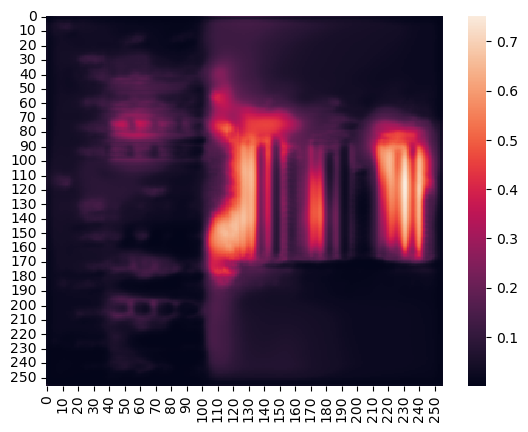

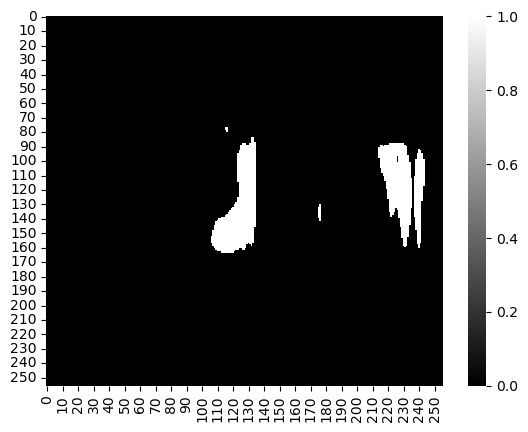

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

with torch.no_grad():
    img_path = os.path.join(TEST_DIR, "45.png")
    print(img_path)
    print(TEST_DIR)

    img = cv2.imread(img_path)
    original_size = img.shape[:2]
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=INTERPOLATION)

    img_tensor = torch.from_numpy(img_resized.astype(np.float32) / 255.0)
    img_tensor = img_tensor.permute(2, 0, 1).unsqueeze(0).contiguous()
    img_tensor = img_tensor.to(DEVICE)

    mask_pred = model(img_tensor)
    mask_pred = torch.sigmoid(mask_pred)
    mask_pred = mask_pred.squeeze().cpu().numpy()  # (H, W)

sns.heatmap(mask_pred)
plt.title("PROB MAP")
plt.show()

sns.heatmap((mask_pred > THRESHOLD), cmap='gray', vmin=0, vmax=1)
plt.title("MASK MAP")
plt.show()



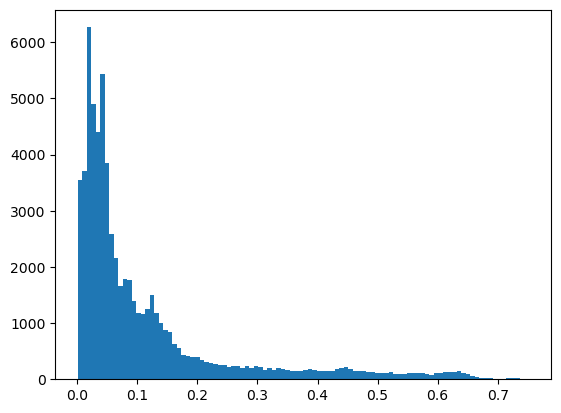

[38541 13092  4619  2341  1751  1720  1324  1044   976   128]


In [370]:
plt.hist(mask_pred.ravel(), bins=100)
plt.show()

hist, _ = np.histogram(mask_pred.ravel(), bins=10)
print(hist)

Predicting:   0%|          | 0/4 [00:00<?, ?it/s]

[DEBUG] Original Img size: (512, 648)
[DEBUG] Predictions Counts of semicolun:  0
[DEBUG]  authentic
[DEBUG] Ground Truth RLE Length for case_id 10:  0
[DEBUG] Original Img size: (1200, 1600)
[DEBUG] Predictions Counts of semicolun:  4
[DEBUG]  [765766, 9, 766966, 9, 768166, 9, 769366, 9, 770566, 9, 771766, 9, 772961, 23, 774161, 23, 775361, 23, 776561, 23, 777761, 23, 778961, 23, 780156, 33, 781356, 33, 782556, 33, 783756, 33, 784956, 33, 786156, 33, 787356, 33, 788556, 33, 789756, 33, 790956, 33, 792156, 33, 793356, 33, 794556, 33, 795756, 33, 796956, 33, 798156, 33, 799356, 33, 800556, 33, 801756, 33, 802961, 28, 804161, 28, 805361, 28, 806561, 28, 807761, 28, 808961, 28, 810170, 14, 811370, 14, 812570, 14, 813770, 14, 814970, 14, 816170, 14, 817370, 14];[1328645, 33, 1329845, 33, 1331045, 33, 1332245, 33, 1333445, 33, 1334645, 33, 1335831, 52, 1337031, 52, 1338231, 52, 1339431, 52, 1340631, 52, 1341831, 52, 1343022, 65, 1344222, 65, 1345422, 65, 1346622, 65, 1347822, 65, 1349022, 6

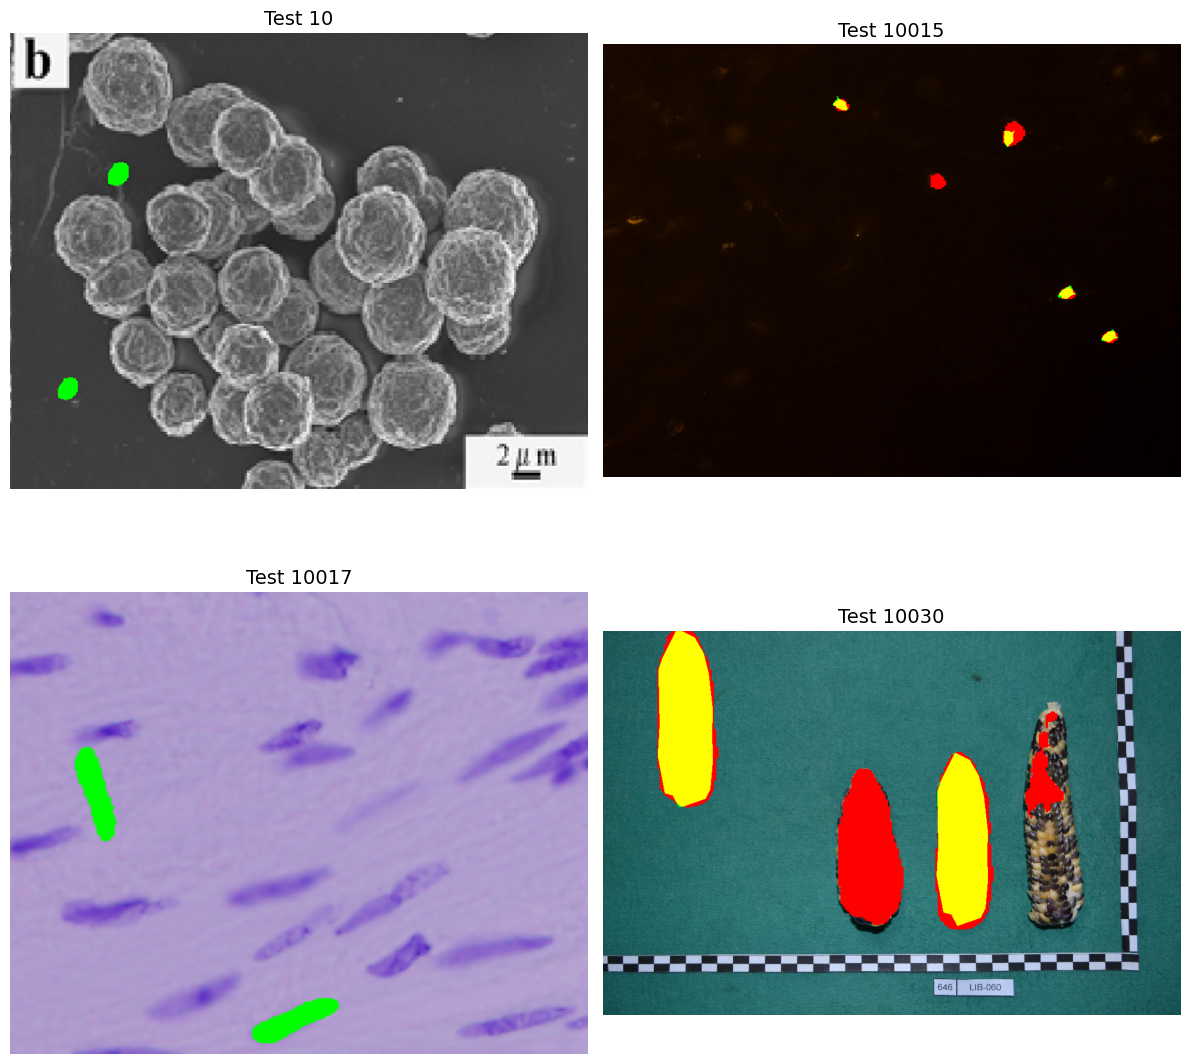

In [371]:
import matplotlib.pyplot as plt

predictions = predict(model, paths['train_forged'], test_path_file_list=None,device=DEVICE, img_size=IMG_SIZE, max_size=4)
sample_ids = predictions['case_id'][:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()

for i, case_id in enumerate(sample_ids):
    case_id = str(case_id)
    base_dir = paths['train_forged']

    # 지원할 확장자 목록
    extensions = [".jpg", ".png", ".jpeg"]
    mask_path = os.path.join(paths['train_masks'], f"{case_id}.npy")
    mask_true = np.load(mask_path)
    h, w = mask_true.shape[1:]

    # 존재하는 확장자 찾기
    img_path = None
    for ext in extensions:
        candidate = os.path.join(base_dir, f"{case_id}{ext}")
        if os.path.exists(candidate):
            img_path = candidate
            break
    if img_path is None:
        print(f"Image for case_id {case_id} not found.")
        continue
    
    predictions_df = pd.DataFrame(predictions)
    pred_str = str(predictions_df.loc[predictions_df['case_id']==int(case_id)]['annotation'].values[0])
    
    print(f"[DEBUG] Original Img size: ({h}, {w})")
    print("[DEBUG] Predictions Counts of semicolun: ", pred_str.count(";"))
    print('[DEBUG] ', pred_str)
    mask_rle = rle_encode([mask_true])
    print(f"[DEBUG] Ground Truth RLE Length for case_id {case_id}: ", mask_rle.count(';'))

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # GT (정답 마스크)
    gt_path = os.path.join(paths['train_masks'], f"{case_id}.npy")
    gt = np.load(gt_path)
    if gt.ndim == 3:
        gt = gt.max(axis=0)

    # RLE decode
    if pred_str == "authentic":
        pred_mask = np.zeros_like(gt)
    else:
        masks = [rle_decode(x, shape=gt.shape) for x in pred_str.split(';')]
        pred_mask = np.clip(np.sum(masks, axis=0), 0, 1)

    # 오버레이
    overlay = img_rgb.copy()
    overlay[(gt > 0) & (pred_mask == 0)] = [0, 255, 0]      # 정답만 있는 곳 (초록)
    overlay[(pred_mask > 0) & (gt == 0)] = [255, 0, 0]      # 예측만 있는 곳 (빨강)
    overlay[(pred_mask > 0) & (gt > 0)] = [255, 255, 0]     # 겹치는 곳 (노랑)

    axes[i].imshow(overlay)
    axes[i].set_title(f"Train {case_id}", fontsize=14)
    axes[i].axis("off")

    # 시각화
    axes[i].imshow(overlay)
    axes[i].set_title(f"Test {case_id}", fontsize=14)
    axes[i].axis('off')



plt.tight_layout()
plt.show()

